# Geopolitical State Classification using Neural Networks

**Objective:** Develop a ML-based classification model that predicts geopolitical state between countries. The model classifies relationships into multiple categories — Peace, Strategic Competition, Cold War, Proxy War, Direct War — based on factors such as military strength, nuclear capabilities, economic condition, ideological difference, political stability, historical conflicts, and sentiment analysis derived from media and public scores. Build and evaluate a neural network model using proper data processing, validation, and testing. Optimise model parameters through hyperparameter tuning and validation strategies.

## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Data Loading & Exploratory Data Analysis (EDA)

In [4]:
df = pd.read_csv("geopolitical_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (1000, 15)


,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
0,1.061810,46,0,20,1.514162,7,0.949273,0.844864,0.934033,5,793.537402,-0.740587,0.084002,0.274637,1
1,1.926071,11,0,157,1.915973,7,0.879601,0.359676,0.766351,6,85.599553,-0.092492,0.681526,0.273081,1
2,1.597991,61,0,268,0.903452,9,0.907042,0.687234,0.657950,0,183.457885,0.013860,0.680110,0.302622,1
3,1.397988,79,0,161,1.213110,6,0.991533,0.312834,0.823896,0,758.403673,0.374780,0.669080,0.612313,1
4,0.734028,87,1,259,1.451510,4,0.208315,0.060906,0.647520,4,21.986522,0.266567,0.942334,0.438333,1


In [5]:
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   military_power_ratio  1000 non-null   float64
 1   troop_movement        1000 non-null   int64  
 2   nuclear_capability    1000 non-null   int64  
 3   nuclear_warheads      1000 non-null   int64  
 4   gdp_ratio             1000 non-null   float64
 5   sanctions_intensity   1000 non-null   int64  
 6   trade_dependency      1000 non-null   float64
 7   ideology_distance     1000 non-null   float64
 8   political_stability   1000 non-null   float64
 9   historical_conflict   1000 non-null   int64  
 10  border_distance       1000 non-null   float64
 11  news_sentiment        1000 non-null   float64
 12  nationalism_index     1000 non-null   float64
 13  leader_aggression     1000 non-null   float64
 14  target                1000 non-null   int64  
dtypes: float64(9

,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.235385,49.160000,0.529000,253.442000,1.279245,4.597000,0.498373,0.497929,0.489480,4.496000,492.823847,-0.018263,0.517017,0.497426,1.595000
std,0.438206,29.131204,0.499408,143.414142,0.425925,2.844412,0.287361,0.289664,0.287191,2.930285,280.927662,0.570455,0.285276,0.295820,0.776903
min,0.506948,0.000000,0.000000,0.000000,0.500664,0.000000,0.000227,0.003918,0.000241,0.000000,0.052827,-0.999518,0.002141,0.000158,0.000000
25%,0.853960,24.000000,0.000000,130.750000,0.927437,2.000000,0.255222,0.245255,0.240101,2.000000,257.662524,-0.511212,0.280303,0.241523,1.000000
50%,1.245211,47.000000,1.000000,259.000000,1.296736,5.000000,0.483831,0.500748,0.481948,5.000000,490.355372,-0.011218,0.523833,0.484278,2.000000
75%,1.616479,75.000000,1.000000,380.250000,1.643959,7.000000,0.749492,0.745443,0.741773,7.000000,724.534469,0.471912,0.765292,0.762728,2.000000
max,1.999577,99.000000,1.000000,499.000000,1.999316,9.000000,0.998793,0.999461,0.999207,9.000000,996.990503,0.999010,0.999673,0.999335,4.000000


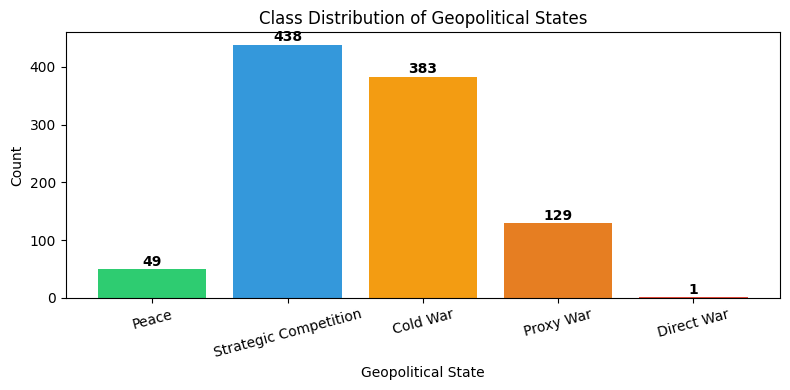

In [6]:
# Class distribution
class_labels = {0: 'Peace', 1: 'Strategic Competition', 2: 'Cold War', 3: 'Proxy War', 4: 'Direct War'}

class_counts = df['target'].value_counts().sort_index()
mapped_labels = [class_labels.get(i, str(i)) for i in class_counts.index]

plt.figure(figsize=(8, 4))
bars = plt.bar(mapped_labels, class_counts.values, color=['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c'])
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Class Distribution of Geopolitical States')
plt.xlabel('Geopolitical State')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

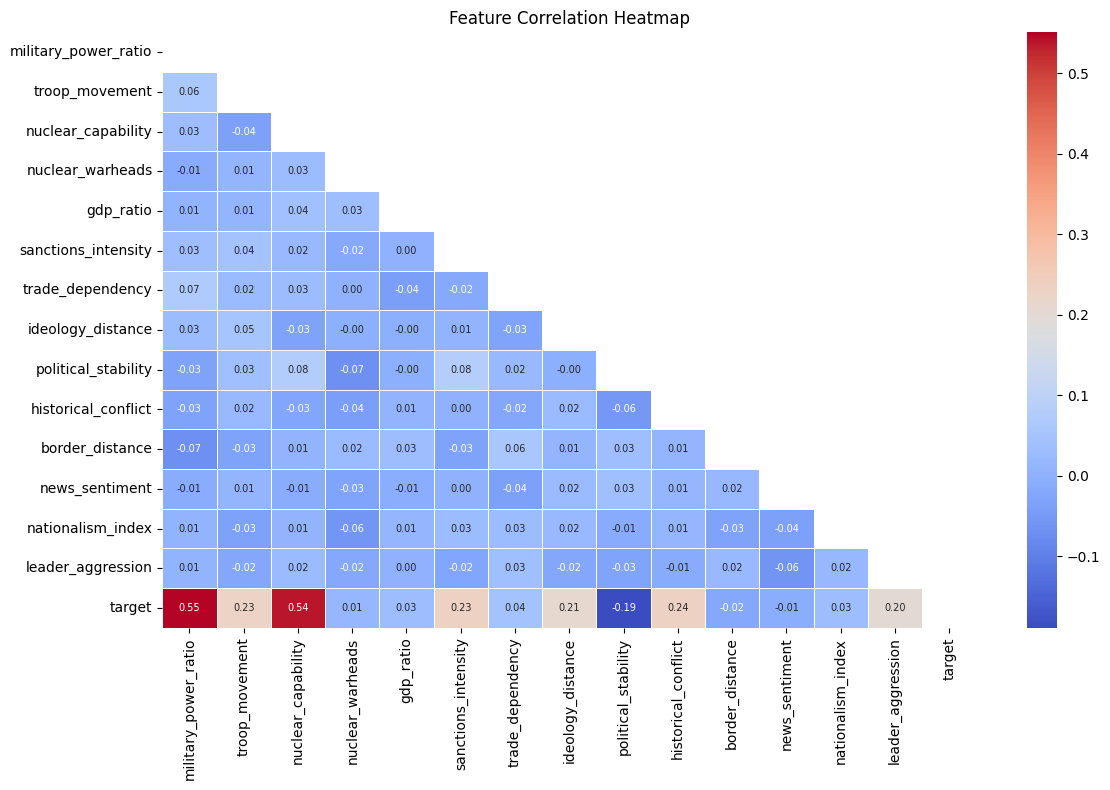

In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [8]:
# Separate features and target
X = df.drop('target', axis=1).values
y = df['target'].values

num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")
print(f"Classes found: {np.unique(y)}")

# One-hot encode target for neural network
y_cat = to_categorical(y, num_classes=num_classes)

# Train / Validation / Test split: 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Number of classes: 5
Classes found: [0 1 2 3 4]


ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [4]

## 4. Neural Network Model

In [9]:
def build_model(input_dim, num_classes, neurons=128, dropout_rate=0.3, learning_rate=0.001):
    """Build a fully-connected neural network for multi-class classification."""
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(neurons // 2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(neurons // 4, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate / 2),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(input_dim=X_train.shape[1], num_classes=num_classes)
model.summary()

NameError: name 'X_train' is not defined

## 5. Model Training with Callbacks

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', color='royalblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Model Evaluation on Test Set

In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n=== Classification Report ===")
target_names = [class_labels[i] for i in range(num_classes)]
print(classification_report(y_true, y_pred, target_names=target_names))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xticklabels(target_names, rotation=30, ha='right')

# Normalised
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=np.round(cm_norm, 2),
                                    display_labels=target_names)
disp_norm.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalised)')
axes[1].set_xticklabels(target_names, rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning (Manual Grid Search)

In [ ]:
param_grid = {
    'neurons':       [64, 128, 256],
    'dropout_rate':  [0.2, 0.3, 0.4],
    'learning_rate': [0.001, 0.0005]
}

results = []

for neurons in param_grid['neurons']:
    for dr in param_grid['dropout_rate']:
        for lr in param_grid['learning_rate']:
            tf.random.set_seed(42)
            m = build_model(X_train.shape[1], num_classes,
                            neurons=neurons, dropout_rate=dr, learning_rate=lr)
            es = EarlyStopping(monitor='val_loss', patience=15,
                               restore_best_weights=True, verbose=0)
            m.fit(X_train, y_train,
                  epochs=80, batch_size=32,
                  validation_data=(X_val, y_val),
                  callbacks=[es], verbose=0)

            _, val_acc = m.evaluate(X_val, y_val, verbose=0)
            results.append({
                'neurons': neurons,
                'dropout_rate': dr,
                'learning_rate': lr,
                'val_accuracy': val_acc
            })
            print(f"neurons={neurons}, dropout={dr}, lr={lr}  ->  val_acc={val_acc:.4f}")

results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
print("\n=== Top 5 Hyperparameter Combinations ===")
print(results_df.head())

## 8. Best Model — Retrain & Final Evaluation

In [ ]:
best = results_df.iloc[0]
print(f"Best params: neurons={int(best['neurons'])}, "
      f"dropout={best['dropout_rate']}, lr={best['learning_rate']}")
print(f"Best val accuracy: {best['val_accuracy']:.4f}")

tf.random.set_seed(42)
best_model = build_model(
    X_train.shape[1], num_classes,
    neurons=int(best['neurons']),
    dropout_rate=best['dropout_rate'],
    learning_rate=best['learning_rate']
)

# Combine train + val for final training
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

best_model.fit(
    X_trainval, y_trainval,
    epochs=150, batch_size=32,
    callbacks=[EarlyStopping(monitor='loss', patience=20,
                              restore_best_weights=True, verbose=0)],
    verbose=0
)

test_loss_b, test_acc_b = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Loss    : {test_loss_b:.4f}")
print(f"Final Test Accuracy: {test_acc_b:.4f} ({test_acc_b*100:.2f}%)")

y_pred_best = np.argmax(best_model.predict(X_test), axis=1)
print("\n=== Final Classification Report ===")
print(classification_report(y_true, y_pred_best, target_names=target_names))

## 9. K-Fold Cross Validation

In [ ]:
# Use raw (unscaled) data for clean k-fold pipeline
X_all = df.drop('target', axis=1).values
y_all = df['target'].values
y_all_cat = to_categorical(y_all, num_classes=num_classes)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    # Scale within each fold to prevent leakage
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_all[train_idx])
    Xvl = sc.transform(X_all[val_idx])
    ytr = y_all_cat[train_idx]
    yvl = y_all_cat[val_idx]

    tf.random.set_seed(42)
    m = build_model(Xtr.shape[1], num_classes,
                    neurons=int(best['neurons']),
                    dropout_rate=best['dropout_rate'],
                    learning_rate=best['learning_rate'])
    m.fit(Xtr, ytr,
          epochs=100, batch_size=32,
          callbacks=[EarlyStopping(monitor='val_loss', patience=15,
                                    restore_best_weights=True, verbose=0)],
          validation_data=(Xvl, yvl),
          verbose=0)

    _, acc = m.evaluate(Xvl, yvl, verbose=0)
    fold_accuracies.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

print(f"\nMean CV Accuracy : {np.mean(fold_accuracies):.4f}")
print(f"Std  CV Accuracy : {np.std(fold_accuracies):.4f}")

In [ ]:
# Visualise K-Fold results
plt.figure(figsize=(7, 4))
plt.bar([f'Fold {i+1}' for i in range(5)], fold_accuracies,
        color='steelblue', edgecolor='black')
plt.axhline(np.mean(fold_accuracies), color='red', linestyle='--',
            label=f'Mean = {np.mean(fold_accuracies):.4f}')
plt.title('5-Fold Cross Validation Accuracies')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Summary

| Step | Detail |
|------|--------|
| **Dataset** | 14 geopolitical features → 5-class target |
| **Preprocessing** | StandardScaler, 70/15/15 stratified split, one-hot encoding |
| **Architecture** | 3 hidden layers (Dense + BatchNorm + Dropout) + Softmax output |
| **Callbacks** | EarlyStopping (patience=20), ReduceLROnPlateau |
| **Tuning** | Manual grid search over neurons, dropout, learning rate |
| **Validation** | 5-Fold Stratified Cross Validation |
| **Metrics** | Accuracy, Precision, Recall, F1-score, Confusion Matrix |